# COMP4124 — Handling Class Imbalance in Big Data using Apache Spark
## Group 8
**Group Members:** Muthukamaran Nallusamy · Rutuj Bafna · Tharun Gurunathan

| Strategy | Type |
|---|---|
| S-00: No Sampling | Baseline |
| S-01: Random Undersampling | Under-sampling |
| S-02: Distributed SMOTE | Over-sampling (custom) |
| S-03: Hybrid — SMOTE + Tomek Links | Hybrid (custom) |
| S-04: EasyEnsemble | Ensemble |

**Scalability tested at:** 10% (~636K rows), 30% (~1.9M rows), 100% (~6.3M rows)

In [0]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.feature import BucketedRandomProjectionLSH
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.sql.types import StructType, StructField, DoubleType
import numpy as np
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pyspark.ml.classification import LogisticRegression

## 2. Data Loading

**Source:** Lopez, E. (2017). PaySim: Simulating Mobile Money Fraud. Kaggle. https://kaggle.com/datasets/ealaxi/paysim1

In [0]:
DATA_PATH = "/mnt/2026-group8/PS_20174392719_1491204439457_log.csv"

df = spark.read.csv(DATA_PATH, header=True, inferSchema=True)

total_rows = df.count()
fraud_rows = df.filter(F.col("isFraud") == 1).count()
legit_rows = total_rows - fraud_rows

print(f"Total rows loaded : {total_rows:,}")
print(f"Fraud cases       : {fraud_rows:,}  ({100 * fraud_rows / total_rows:.2f}%)")
print(f"Legitimate cases  : {legit_rows:,}  ({100 * legit_rows / total_rows:.2f}%)")
print(f"Imbalance ratio   : {legit_rows // fraud_rows}:1")

Total rows loaded : 6,362,620
Fraud cases       : 8,213  (0.13%)
Legitimate cases  : 6,354,407  (99.87%)
Imbalance ratio   : 773:1


## 3. Feature Engineering
Encode transaction type, prepare label.

In [0]:
df = df.withColumn("typeEncoded",
    F.when(F.col("type") == "TRANSFER",  1.0)
     .when(F.col("type") == "CASH_OUT",  2.0)
     .when(F.col("type") == "PAYMENT",   3.0)
     .when(F.col("type") == "CASH_IN",   4.0)
     .otherwise(0.0))  

df = df.withColumn("label", F.col("isFraud").cast("double"))

print("Feature engineering complete.")
df.select("type", "typeEncoded", "label").show(5)

Feature engineering complete.
+--------+-----------+-----+
|    type|typeEncoded|label|
+--------+-----------+-----+
| PAYMENT|        3.0|  0.0|
| PAYMENT|        3.0|  0.0|
|TRANSFER|        1.0|  1.0|
|CASH_OUT|        2.0|  1.0|
| PAYMENT|        3.0|  0.0|
+--------+-----------+-----+
only showing top 5 rows



## 4. Feature Vectorisation and Scaling
Scaling is critical for SMOTE: without it, balance columns (values up to 10M+) dominate Euclidean distance, producing meaningless nearest neighbours.

In [0]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

FEATURE_COLS = [
    "step", "amount",
    "oldbalanceOrg",  "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest",
    "typeEncoded"
]

assembler = VectorAssembler(inputCols=FEATURE_COLS, outputCol="raw_features")
df_vector = assembler.transform(df)

scaler    = StandardScaler(inputCol="raw_features", outputCol="features",
                           withMean=True, withStd=True)
df_scaled = scaler.fit(df_vector).transform(df_vector)
df_scaled = df_scaled.cache()

print(f"Scaled dataset cached. Total rows: {df_scaled.count():,}")

Scaled dataset cached. Total rows: 6,362,620


## 5. Sampling Strategies

### S-01: Random Undersampling
Removes majority-class samples randomly to reach 1:2 ratio.

In [0]:
def random_undersample(train_df, seed=42):
    fraud = train_df.filter(F.col("label") == 1.0)
    legit = train_df.filter(F.col("label") == 0.0)

    fraud_count = fraud.count()
    legit_count = legit.count()

    fraction = min((fraud_count * 2) / legit_count, 1.0)
    sampled_legit = legit.sample(withReplacement=False, fraction=fraction, seed=seed)
    balanced      = fraud.union(sampled_legit)

    print(f"  [S-01] Balanced: {balanced.count():,} rows (fraud: {fraud_count:,} | legit sampled: {sampled_legit.count():,})")
    return balanced

### S-02: Distributed SMOTE (custom)
Custom distributed SMOTE using Spark RDDs and broadcast variables.

**Design:** Minority samples collected to driver (0.13% = ~8,200 rows — manageable). Features broadcast to all 4 workers. Synthetic generation parallelised via `mapPartitions`. Multiplier capped at 50x to prevent OOM at 100% scale.

In [0]:
def compute_knn_indices(sample, all_samples, k=5):
    sample_arr = np.array(sample)
    distances  = [(i, np.linalg.norm(sample_arr - np.array(s)))
                  for i, s in enumerate(all_samples)]
    distances.sort(key=lambda x: x[1])
    return [distances[i][0] for i in range(1, k + 1)]


def smote_oversample(train_df, k=5, target_ratio=1.0, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    fraud_df = train_df.filter(F.col("label") == 1.0)
    legit_df = train_df.filter(F.col("label") == 0.0)

    fraud_count = fraud_df.count()
    legit_count = legit_df.count()

    # Dynamic multiplier capped at 50x to prevent memory overflow at 100% scale
    target_fraud          = int(legit_count * target_ratio)
    oversample_multiplier = min(max(1, (target_fraud - fraud_count) // max(fraud_count, 1)), 50)
    print(f"  [S-02] Fraud: {fraud_count:,} | Legit: {legit_count:,} | Multiplier: {oversample_multiplier}x")

    # Collect minority class to driver (~8,200 rows at 100% scale) and broadcast
    fraud_rows     = fraud_df.collect()
    fraud_features = [list(row["features"]) for row in fraud_rows]
    n_fraud        = len(fraud_features)

    bc_fraud = spark.sparkContext.broadcast(fraud_features)

    # Parallelise generation across 4 worker nodes
    fraud_indices_rdd = spark.sparkContext.parallelize(range(n_fraud), numSlices=4)

    def generate_synthetic(partition_indices):
        all_fraud = bc_fraud.value
        synthetic = []
        rng       = random.Random(seed)
        for idx in partition_indices:
            sample     = all_fraud[idx]
            nn_indices = compute_knn_indices(sample, all_fraud, k=k)
            for _ in range(oversample_multiplier):
                nn_idx    = rng.choice(nn_indices)
                neighbour = all_fraud[nn_idx]
                lam       = rng.random()
                new_point = [sample[j] + lam * (neighbour[j] - sample[j])
                             for j in range(len(sample))]
                synthetic.append(new_point)
        return iter(synthetic)

    synthetic_rdd    = fraud_indices_rdd.mapPartitions(generate_synthetic)
    synthetic_schema = StructType([
        StructField("features", VectorUDT(), False),
        StructField("label",    DoubleType(), False)
    ])
    synthetic_rows = synthetic_rdd.map(lambda f: (Vectors.dense(f), 1.0))
    synthetic_df   = spark.createDataFrame(synthetic_rows, schema=synthetic_schema)
    result         = train_df.select("features", "label").union(synthetic_df)

    bc_fraud.unpersist()
    print(f"  [S-02] Generated {synthetic_df.count():,} synthetic samples. Total: {result.count():,}")
    return result

### S-03: Hybrid — SMOTE then Tomek Links
SMOTE first (oversample), then Tomek Links (clean boundary).

Tomek Links use `BucketedRandomProjectionLSH` — avoids O(n²) exact distance computation infeasible at 6M+ rows. Documented as an approximation.

In [0]:
def remove_tomek_links(df, distance_threshold=2.0, majority_limit=10000):
    print(f"  [S-03 Tomek] LSH boundary cleaning (threshold={distance_threshold})...")

    row_count = df.count()                        
    majority_limit = int(row_count * 0.002)
    before = row_count                            

    df_with_id = df.withColumn("row_id", F.monotonically_increasing_id())

    brp = BucketedRandomProjectionLSH(
        inputCol="features", outputCol="hashes",
        bucketLength=20.0, numHashTables=3
    )
    lsh_model = brp.fit(df_with_id)

    majority_sample = (df_with_id.filter(F.col("label") == 0.0)
                                 .orderBy(F.rand(seed=42))
                                 .limit(majority_limit))
    minority_all    = df_with_id.filter(F.col("label") == 1.0)

    links     = lsh_model.approxSimilarityJoin(majority_sample, minority_all,
                                               distance_threshold, distCol="EuclideanDistance")
    tomek_ids = (links.select(F.col("datasetA.row_id").alias("row_id")).distinct())

    cleaned = (df_with_id.join(F.broadcast(tomek_ids), on="row_id", how="left_anti")
                         .drop("row_id"))

    after = cleaned.count()
    print(f"  [S-03 Tomek] Removed {before - after:,} boundary samples ({before:,} → {after:,})")
    return cleaned


def hybrid_smote_tomek(train_df, k=5, target_ratio=1.0, seed=42):
    print("  [S-03] Phase 1: SMOTE oversampling...")
    smoted = smote_oversample(train_df, k=k, target_ratio=target_ratio, seed=seed)
    smoted = smoted.cache()
    smoted.count()                  

    print("  [S-03] Phase 2: Tomek Links cleaning...")
    result = remove_tomek_links(smoted)
    result = result.cache()         
    result.count()                  

    smoted.unpersist()              
    return result

### S-04: EasyEnsemble
Trains multiple Random Forest classifiers on different balanced subsets, aggregates by averaging prediction scores (threshold 0.5). Different seed per estimator ensures diverse majority subsets.

In [0]:
def easy_ensemble_train(train_df, n_estimators=5, num_trees=10):
    fraud_df    = train_df.filter(F.col("label") == 1.0)
    legit_df    = train_df.filter(F.col("label") == 0.0)
    fraud_count = fraud_df.count()
    legit_count = legit_df.count()
    fraction    = min(fraud_count / legit_count, 1.0)

    models = []
    print(f"  [S-04] Training {n_estimators} estimators (fraud: {fraud_count:,})...")

    for i in range(n_estimators):
        sampled_legit = legit_df.sample(withReplacement=False, fraction=fraction, seed=42 + i)
        balanced_sub  = fraud_df.union(sampled_legit)
        rf            = RandomForestClassifier(featuresCol="features", labelCol="label",
                                               numTrees=num_trees, seed=42 + i)
        models.append(rf.fit(balanced_sub))
        print(f"  [S-04] Estimator {i+1}/{n_estimators} done.")

    return models


def easy_ensemble_predict(models, test_df):
    results = test_df
    for i, m in enumerate(models):
        results = m.transform(results)
        results = (results
                   .withColumnRenamed("probability",   f"prob_{i}")
                   .withColumnRenamed("prediction",    f"pred_{i}")
                   .withColumnRenamed("rawPrediction", f"rawPred_{i}"))

    pred_cols = [f"pred_{i}" for i in range(len(models))]
    avg_expr  = sum(F.col(c) for c in pred_cols) / len(models)

    return (results
            .withColumn("ensemble_score", avg_expr)
            .withColumn("prediction",
                        F.when(F.col("ensemble_score") >= 0.5, 1.0).otherwise(0.0))
            .withColumnRenamed("rawPred_0", "rawPrediction"))

## 6. Evaluation Helper
Computes all metrics consistently across every strategy.

In [0]:
mc_evaluator  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
bin_evaluator = BinaryClassificationEvaluator(labelCol="label",
                                              rawPredictionCol="rawPrediction",
                                              metricName="areaUnderROC")

def evaluate_predictions(preds):
    f1       = mc_evaluator.evaluate(preds, {mc_evaluator.metricName: "f1"})
    accuracy = mc_evaluator.evaluate(preds, {mc_evaluator.metricName: "accuracy"})

    tp = preds.filter((F.col("label") == 1.0) & (F.col("prediction") == 1.0)).count()
    fn = preds.filter((F.col("label") == 1.0) & (F.col("prediction") == 0.0)).count()
    fp = preds.filter((F.col("label") == 0.0) & (F.col("prediction") == 1.0)).count()

    fraud_recall = round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0.0
    fraud_prec   = round(tp / (tp + fp), 4) if (tp + fp) > 0 else 0.0

    try:
        auc = round(bin_evaluator.evaluate(preds), 4)
    except Exception:
        auc = float("nan")

    print(f"    F1 (weighted)   : {f1:.4f}")
    print(f"    Accuracy        : {accuracy:.4f}")
    print(f"    Fraud Recall    : {fraud_recall:.4f}")
    print(f"    Fraud Precision : {fraud_prec:.4f}")
    print(f"    AUC-ROC         : {auc:.4f}")

    return {"F1": round(f1,4), "Accuracy": round(accuracy,4), "Fraud_Recall": fraud_recall, "Fraud_Precision": fraud_prec, "AUC_ROC": auc}

## 7. Scalability Experiment
Runs all 5 strategies at 10%, 30%, and 100% data scales.

- Stratified `sampleBy` preserves 769:1 class ratio at each scale
- 80/20 train/test split, seed=42 throughout
- Test set cached for fair timing
- `numTrees=10`, `n_estimators=5` for runtime manageability

In [0]:
DATA_FRACTIONS      = {"10%": 0.1, "30%": 0.3, "100%": 1.0}
scalability_results = []

for size_label, fraction in DATA_FRACTIONS.items():
    print(f"\n{'='*60}\n  SCALE: {size_label}\n{'='*60}")

    subset    = df_scaled.sampleBy("label", fractions={0.0: fraction, 1.0: fraction}, seed=42)
    row_count = subset.count()
    fraud_count = subset.filter(F.col("label") == 1.0).count()
    print(f"  Subset: {row_count:,} rows | fraud: {fraud_count:,} | legit: {row_count-fraud_count:,}")

    train_s, test_s = subset.randomSplit([0.8, 0.2], seed=42)
    test_s = test_s.cache()

    standard_strategies = [
        ("S-00: No Sampling (baseline)",  lambda t: t),
        ("S-01: Undersampling",           lambda t: random_undersample(t)),
        ("S-02: SMOTE",                   lambda t: smote_oversample(t, k=5, target_ratio=1.0)),
        ("S-03: Hybrid (SMOTE+Tomek)",    lambda t: hybrid_smote_tomek(t, k=5, target_ratio=1.0)),
    ]

    for strat_label, strategy_func in standard_strategies:
        print(f"\n  --- {strat_label} ---")
        t0             = time.time()
        train_balanced = strategy_func(train_s)
        rf             = RandomForestClassifier(featuresCol="features", labelCol="label",
                                                numTrees=10, seed=42)
        preds          = rf.fit(train_balanced).transform(test_s)
        exec_time      = round(time.time() - t0, 2)

        metrics = evaluate_predictions(preds)
        metrics.update({"Scale": size_label, "Rows": row_count,
                        "Strategy": strat_label, "Time_Sec": exec_time})
        scalability_results.append(metrics)
        print(f"  Time: {exec_time}s")

    # S-04: EasyEnsemble handled separately (returns multiple models)
    print(f"\n  --- S-04: EasyEnsemble ---")
    t0              = time.time()
    ensemble_models = easy_ensemble_train(train_s, n_estimators=5, num_trees=10)
    ensemble_preds  = easy_ensemble_predict(ensemble_models, test_s)
    exec_time       = round(time.time() - t0, 2)

    metrics = evaluate_predictions(ensemble_preds)
    metrics.update({"Scale": size_label, "Rows": row_count,
                    "Strategy": "S-04: EasyEnsemble", "Time_Sec": exec_time})
    scalability_results.append(metrics)
    print(f"  Time: {exec_time}s")

    test_s.unpersist()

print("\n\nAll experiments complete.")


  SCALE: 10%
  Subset: 636,780 rows | fraud: 822 | legit: 635,958

  --- S-00: No Sampling (baseline) ---
    F1 (weighted)   : 0.9991
    Accuracy        : 0.9992  [note: equals weightedRecall in Spark]
    Fraud Recall    : 0.3742  <- PRIMARY METRIC
    Fraud Precision : 1.0000
    AUC-ROC         : 0.9501
  Time: 8.15s

  --- S-01: Undersampling ---
  [S-01] Balanced: 1,310 rows (fraud: 667 | legit sampled: 643)
    F1 (weighted)   : 0.9697
    Accuracy        : 0.9435  [note: equals weightedRecall in Spark]
    Fraud Recall    : 0.9806  <- PRIMARY METRIC
    Fraud Precision : 0.0206
    AUC-ROC         : 0.9941
  Time: 15.1s

  --- S-02: SMOTE ---
  [S-02] Fraud: 667 | Legit: 508,515 | Multiplier: 50x
  [S-02] Generated 33,350 synthetic samples. Total: 542,532
    F1 (weighted)   : 0.9990
    Accuracy        : 0.9989  [note: equals weightedRecall in Spark]
    Fraud Recall    : 0.7097  <- PRIMARY METRIC
    Fraud Precision : 0.5392
    AUC-ROC         : 0.9912
  Time: 24.61s

  --

In [0]:
from pyspark.ml.classification import LogisticRegression

DATA_FRACTIONS = {"10%": 0.1, "30%": 0.3, "100%": 1.0}
lr_results = []

for size_label, fraction in DATA_FRACTIONS.items():
    print(f"\n{'='*60}\n  SCALE: {size_label}  [Logistic Regression]\n{'='*60}")

    subset = df_scaled.sampleBy("label", fractions={0.0: fraction, 1.0: fraction}, seed=42)
    row_count = subset.count()
    fraud_count = subset.filter(F.col("label") == 1.0).count()
    print(f"  Subset: {row_count:,} rows | fraud: {fraud_count:,} | legit: {row_count - fraud_count:,}")

    train_s, test_s = subset.randomSplit([0.8, 0.2], seed=42)
    train_s.cache()
    test_s.cache()


    test_lr = test_s.select("features", "label")

    standard_strategies = [
        ("S-00: No Sampling (baseline)", lambda t: t),
        ("S-01: Undersampling",          lambda t: random_undersample(t)),
        ("S-02: SMOTE",                  lambda t: smote_oversample(t, k=5, target_ratio=1.0)),
        ("S-03: Hybrid (SMOTE+Tomek)",   lambda t: hybrid_smote_tomek(t, k=5, target_ratio=1.0)),
    ]

    for strat_label, strategy_func in standard_strategies:
        print(f"\n  --- {strat_label} ---")
        t0 = time.time()
        train_balanced = strategy_func(train_s)
        train_lr = train_balanced.select("features", "label")

        lr_clf = LogisticRegression(
            featuresCol="features",
            labelCol="label",
            maxIter=20,
            regParam=0.01,
            elasticNetParam=0.0
        )
        preds = lr_clf.fit(train_lr).transform(test_lr)
        exec_time = round(time.time() - t0, 2)

        metrics = evaluate_predictions(preds, strat_label)
        metrics.update({
            "Scale": size_label,
            "Rows": row_count,
            "Strategy": strat_label,
            "Time_Sec": exec_time
        })
        lr_results.append(metrics)
        print(f"  Time: {exec_time}s")

    # S-04: EasyEnsemble with LR
    print(f"\n  --- S-04: EasyEnsemble (LR) ---")
    t0 = time.time()

    fraud_df = train_s.filter(F.col("label") == 1.0)
    legit_df = train_s.filter(F.col("label") == 0.0)
    fraud_count_train = fraud_df.count()
    fraction_ee = min(fraud_count_train / legit_df.count(), 1.0)

    n_estimators = 5
    ensemble_preds_lr = test_lr

    for i in range(n_estimators):
        sampled_legit = legit_df.select("features", "label").sample(
            withReplacement=False, fraction=fraction_ee, seed=42 + i
        )
        balanced_sub = fraud_df.select("features", "label").union(sampled_legit)

        lr_ee = LogisticRegression(
            featuresCol="features",
            labelCol="label",
            maxIter=20,
            regParam=0.01,
            elasticNetParam=0.0
        )
        lr_model = lr_ee.fit(balanced_sub)
        ensemble_preds_lr = lr_model.transform(ensemble_preds_lr)
        ensemble_preds_lr = (
            ensemble_preds_lr
            .withColumnRenamed("probability",   f"prob_{i}")
            .withColumnRenamed("prediction",    f"pred_{i}")
            .withColumnRenamed("rawPrediction", f"rawPred_{i}")
        )
        print(f"  [S-04 LR] Estimator {i+1}/{n_estimators} done.")

    pred_cols = [f"pred_{i}" for i in range(n_estimators)]
    avg_expr = sum(F.col(c) for c in pred_cols) / n_estimators

    ensemble_preds_lr = (
        ensemble_preds_lr
        .withColumn("ensemble_score", avg_expr)
        .withColumn("prediction", F.when(F.col("ensemble_score") >= 0.5, 1.0).otherwise(0.0))
        .withColumnRenamed("rawPred_0", "rawPrediction")
    )

    exec_time = round(time.time() - t0, 2)
    metrics = evaluate_predictions(ensemble_preds_lr, "S-04: EasyEnsemble")
    metrics.update({
        "Scale": size_label,
        "Rows": row_count,
        "Strategy": "S-04: EasyEnsemble",
        "Time_Sec": exec_time
    })
    lr_results.append(metrics)
    print(f"  Time: {exec_time}s")

    test_s.unpersist()
    train_s.unpersist()

print("\n\nLR experiments complete.")

lr_df = pd.DataFrame(lr_results)
print("\n=== LR FULL RESULTS ===")
display(lr_df)


  SCALE: 10%  [Logistic Regression]
  Subset: 636,308 rows | fraud: 801 | legit: 635,507

  --- S-00: No Sampling (baseline) ---
    F1 (weighted)   : 0.9981
    Accuracy        : 0.9987  [note: equals weightedRecall in Spark]
    Fraud Recall    : 0.0000  <- PRIMARY METRIC
    Fraud Precision : 0.0000
    AUC-ROC         : 0.8981
  Time: 41.93s

  --- S-01: Undersampling ---
  [S-01] Balanced: 1,267 rows (fraud: 643 | legit sampled: 624)
    F1 (weighted)   : 0.9263
    Accuracy        : 0.8649  [note: equals weightedRecall in Spark]
    Fraud Recall    : 0.8671  <- PRIMARY METRIC
    Fraud Precision : 0.0079
    AUC-ROC         : 0.9141
  Time: 28.64s

  --- S-02: SMOTE ---
  [S-02] Fraud: 643 | Legit: 508,827 | Multiplier: 50x
  [S-02] Generated 32,150 synthetic samples. Total: 541,620
    F1 (weighted)   : 0.9974
    Accuracy        : 0.9969  [note: equals weightedRecall in Spark]
    Fraud Recall    : 0.1646  <- PRIMARY METRIC
    Fraud Precision : 0.0919
    AUC-ROC         : 0.

F1,Accuracy,W_Precision,Fraud_Recall,Fraud_Precision,AUC_ROC,Scale,Rows,Strategy,Time_Sec
0.9981,0.9987,0.9975,0.0,0.0,0.8981,10%,636308,S-00: No Sampling (baseline),41.93
0.9263,0.8649,0.9986,0.8671,0.0079,0.9141,10%,636308,S-01: Undersampling,28.64
0.9974,0.9969,0.9978,0.1646,0.0919,0.904,10%,636308,S-02: SMOTE,83.5
0.9974,0.9969,0.9978,0.1646,0.0919,0.904,10%,636308,S-03: Hybrid (SMOTE+Tomek),116.31
0.9271,0.8663,0.9986,0.8608,0.008,0.9141,10%,636308,S-04: EasyEnsemble,122.81
0.9981,0.9987,0.9974,0.0,0.0,0.9114,30%,1909527,S-00: No Sampling (baseline),29.72
0.9284,0.8685,0.9985,0.8293,0.0081,0.9193,30%,1909527,S-01: Undersampling,28.49
0.9975,0.9971,0.9979,0.2093,0.1259,0.9175,30%,1909527,S-02: SMOTE,61.17
0.9975,0.9971,0.9978,0.2093,0.1253,0.9175,30%,1909527,S-03: Hybrid (SMOTE+Tomek),158.63
0.9296,0.8706,0.9985,0.8272,0.0082,0.9193,30%,1909527,S-04: EasyEnsemble,122.1


## 8. Results Table
Full results and best strategy per scale ranked by Fraud Recall (primary metric).

In [0]:
import pandas as pd

rf_df = pd.DataFrame(scalability_results)
rf_df["Classifier"] = "RF"

lr_df = pd.DataFrame(lr_results)
lr_df["Classifier"] = "LR"

combined_df = pd.concat([rf_df, lr_df], ignore_index=True)

col_order = ["Classifier", "Scale", "Rows", "Strategy",
             "Fraud_Recall", "Fraud_Precision", "AUC_ROC", "F1", "Time_Sec"]
combined_df = combined_df[[c for c in col_order if c in combined_df.columns]]

print("=" * 80)
print("  FULL RESULTS — RF vs LR")
print("=" * 80)
display(combined_df.sort_values(["Scale", "Strategy", "Classifier"]))

# Best strategy per scale per classifier ranked by Fraud Recall
print("\n=== BEST STRATEGY PER SCALE (by Fraud Recall) ===")
best = combined_df.loc[combined_df.groupby(["Scale", "Classifier"])["Fraud_Recall"].idxmax()]
display(best[["Classifier", "Scale", "Strategy", "Fraud_Recall", "Fraud_Precision", "AUC_ROC", "F1", "Time_Sec"]])

  FULL RESULTS — RF vs LR


Classifier,Scale,Rows,Strategy,Fraud_Recall,Fraud_Precision,AUC_ROC,F1,Time_Sec
LR,10%,636308,S-00: No Sampling (baseline),0.0,0.0,0.8981,0.9981,41.93
RF,10%,636780,S-00: No Sampling (baseline),0.3742,1.0,0.9501,NaN,8.15
LR,10%,636308,S-01: Undersampling,0.8671,0.0079,0.9141,0.9263,28.64
RF,10%,636780,S-01: Undersampling,0.9806,0.0206,0.9941,NaN,15.1
LR,10%,636308,S-02: SMOTE,0.1646,0.0919,0.904,0.9974,83.5
RF,10%,636780,S-02: SMOTE,0.7097,0.5392,0.9912,NaN,24.61
LR,10%,636308,S-03: Hybrid (SMOTE+Tomek),0.1646,0.0919,0.904,0.9974,116.31
RF,10%,636780,S-03: Hybrid (SMOTE+Tomek),0.6645,0.9196,0.9887,NaN,49.56
LR,10%,636308,S-04: EasyEnsemble,0.8608,0.008,0.9141,0.9271,122.81
RF,10%,636780,S-04: EasyEnsemble,0.9806,0.0256,0.9941,NaN,103.18



=== BEST STRATEGY PER SCALE (by Fraud Recall) ===


Classifier,Scale,Strategy,Fraud_Recall,Fraud_Precision,AUC_ROC,F1,Time_Sec
LR,10%,S-01: Undersampling,0.8671,0.0079,0.9141,0.9263,28.64
RF,10%,S-01: Undersampling,0.9806,0.0206,0.9941,NaN,15.1
LR,100%,S-04: EasyEnsemble,0.8401,0.008,0.9228,0.9263,251.02
RF,100%,S-04: EasyEnsemble,0.9812,0.027,0.9964,NaN,411.02
LR,30%,S-01: Undersampling,0.8293,0.0081,0.9193,0.9284,28.49
RF,30%,S-01: Undersampling,0.9865,0.0291,0.9955,NaN,82.38


## 9. Visualisations

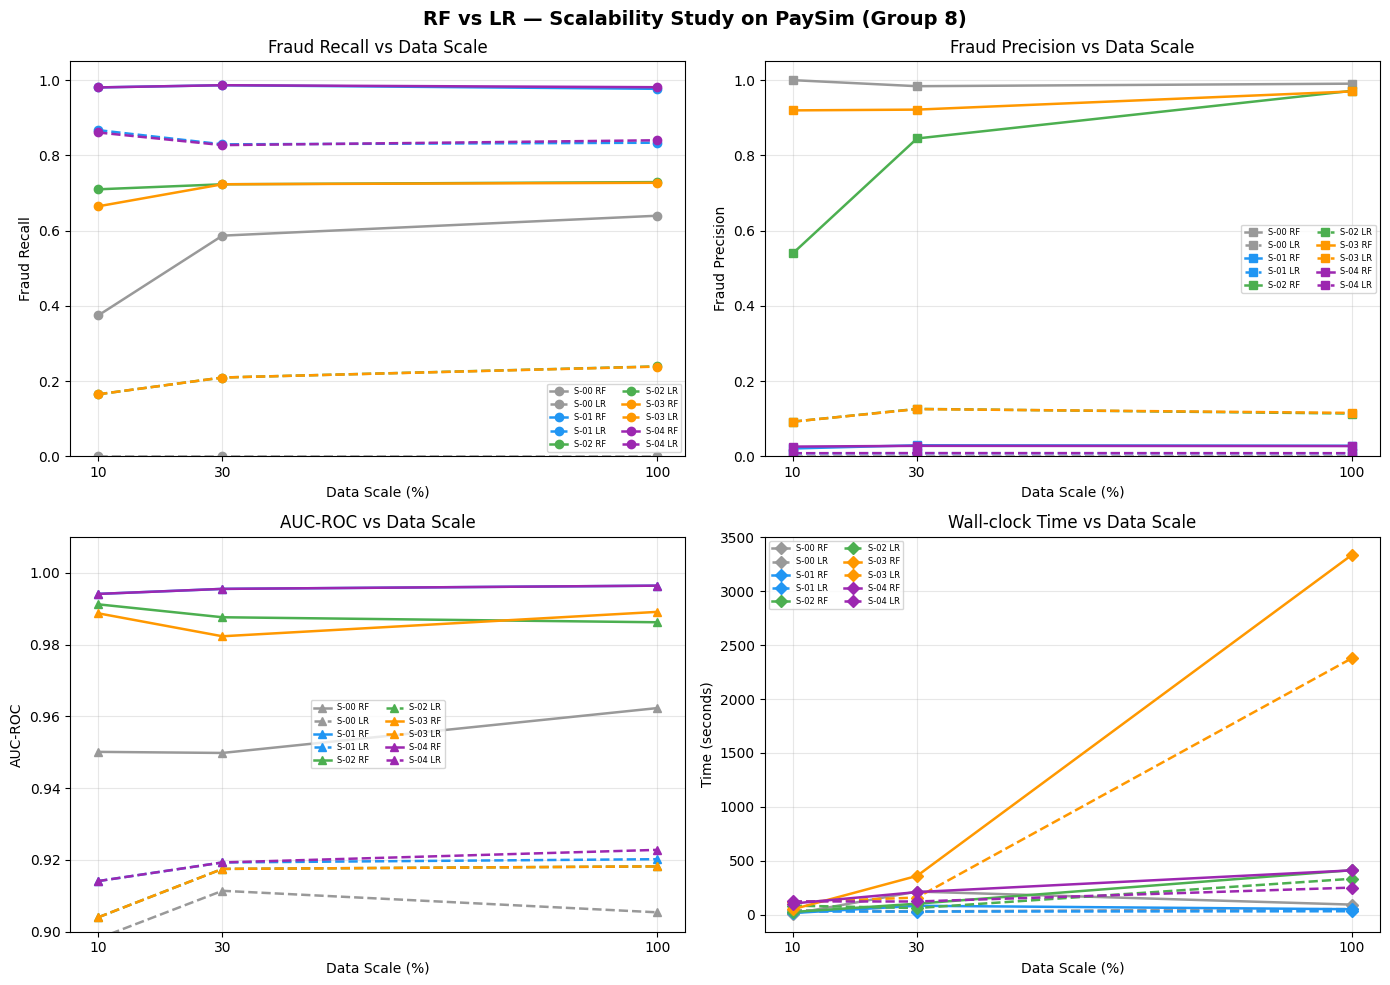

Figure saved as RF_vs_LR_scalability.png


In [0]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

rf_df = pd.DataFrame(scalability_results); rf_df["Classifier"] = "RF"
lr_df = pd.DataFrame(lr_results);         lr_df["Classifier"] = "LR"
combined_df = pd.concat([rf_df, lr_df], ignore_index=True)

scale_order    = ["10%", "30%", "100%"]
strategies     = ["S-00: No Sampling (baseline)", "S-01: Undersampling",
                  "S-02: SMOTE", "S-03: Hybrid (SMOTE+Tomek)", "S-04: EasyEnsemble"]
colors         = ["#999999", "#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]
scale_positions = [10, 30, 100]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("RF vs LR — Scalability Study on PaySim (Group 8)", fontsize=14, fontweight="bold")

# --- Plot 1: Fraud Recall vs Scale ---
ax = axes[0, 0]
for i, strat in enumerate(strategies):
    short = strat.split(":")[0]
    for clf, ls in [("RF", "-"), ("LR", "--")]:
        sub = combined_df[(combined_df["Strategy"] == strat) & (combined_df["Classifier"] == clf)]
        sub = sub.set_index("Scale").reindex(scale_order)
        ax.plot(scale_positions, sub["Fraud_Recall"].values,
                color=colors[i], linestyle=ls, marker="o",
                label=f"{short} {clf}", linewidth=1.8)
ax.set_title("Fraud Recall vs Data Scale")
ax.set_xlabel("Data Scale (%)")
ax.set_ylabel("Fraud Recall")
ax.set_xticks(scale_positions)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

# --- Plot 2: Fraud Precision vs Scale ---
ax = axes[0, 1]
for i, strat in enumerate(strategies):
    short = strat.split(":")[0]
    for clf, ls in [("RF", "-"), ("LR", "--")]:
        sub = combined_df[(combined_df["Strategy"] == strat) & (combined_df["Classifier"] == clf)]
        sub = sub.set_index("Scale").reindex(scale_order)
        ax.plot(scale_positions, sub["Fraud_Precision"].values,
                color=colors[i], linestyle=ls, marker="s",
                label=f"{short} {clf}", linewidth=1.8)
ax.set_title("Fraud Precision vs Data Scale")
ax.set_xlabel("Data Scale (%)")
ax.set_ylabel("Fraud Precision")
ax.set_xticks(scale_positions)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

# --- Plot 3: AUC-ROC vs Scale ---
ax = axes[1, 0]
for i, strat in enumerate(strategies):
    short = strat.split(":")[0]
    for clf, ls in [("RF", "-"), ("LR", "--")]:
        sub = combined_df[(combined_df["Strategy"] == strat) & (combined_df["Classifier"] == clf)]
        sub = sub.set_index("Scale").reindex(scale_order)
        ax.plot(scale_positions, sub["AUC_ROC"].values,
                color=colors[i], linestyle=ls, marker="^",
                label=f"{short} {clf}", linewidth=1.8)
ax.set_title("AUC-ROC vs Data Scale")
ax.set_xlabel("Data Scale (%)")
ax.set_ylabel("AUC-ROC")
ax.set_xticks(scale_positions)
ax.set_ylim(0.9, 1.01)
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

# --- Plot 4: Time vs Scale ---
ax = axes[1, 1]
for i, strat in enumerate(strategies):
    short = strat.split(":")[0]
    for clf, ls in [("RF", "-"), ("LR", "--")]:
        sub = combined_df[(combined_df["Strategy"] == strat) & (combined_df["Classifier"] == clf)]
        sub = sub.set_index("Scale").reindex(scale_order)
        ax.plot(scale_positions, sub["Time_Sec"].values,
                color=colors[i], linestyle=ls, marker="D",
                label=f"{short} {clf}", linewidth=1.8)
ax.set_title("Wall-clock Time vs Data Scale")
ax.set_xlabel("Data Scale (%)")
ax.set_ylabel("Time (seconds)")
ax.set_xticks(scale_positions)
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("RF_vs_LR_scalability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as RF_vs_LR_scalability.png")